In [3]:
pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 24.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires 

In [4]:
pip install kernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 10.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Testing 


In [5]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape)
print(y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)


In [7]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
#  loading the data set
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()


In [9]:
x_train = x_train / 255.0
x_test = x_test / 255.0
# Convert labels to one-hot encoding
y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


# MLP (build)****

In [10]:
model = Sequential([
    Flatten(input_shape=(28, 28)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-06-09 21:41:48.685865: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Manual Cross-Entropy Function

In [12]:
def custom_cross_entropy(y_true, y_pred):

    epsilon = 1e-12

    # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1.0)

    loss = -np.sum(y_true * np.log(y_pred), axis=1)

    return np.mean(loss)

# Compile and Train Model

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8905 - loss: 0.3010 - val_accuracy: 0.8683 - val_loss: 0.3624
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8964 - loss: 0.2838 - val_accuracy: 0.8768 - val_loss: 0.3452
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9010 - loss: 0.2697 - val_accuracy: 0.8857 - val_loss: 0.3190
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9040 - loss: 0.2623 - val_accuracy: 0.8875 - val_loss: 0.3135
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9046 - loss: 0.2534 - val_accuracy: 0.8812 - val_loss: 0.3344
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9097 - loss: 0.2436 - val_accuracy: 0.8855 - val_loss: 0.3150
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9111 - loss: 0.2366 - val_accuracy: 0.8855 - val_loss: 0.3128
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9157 - loss: 0.2262 - val_accuracy: 0.

# Get Prediction Probabilities

In [15]:
pred_probs = model.predict(x_test)

pred_classes = np.argmax(pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [17]:
def compute_entropy(probabilities):

    epsilon = 1e-12

    probabilities = np.clip(probabilities, epsilon, 1.0)

    entropy = -np.sum(probabilities * np.log(probabilities), axis=1)

    return entropy

# Calculate Entropy Values

In [18]:
entropy_values = compute_entropy(pred_probs)

print("First 10 entropy values:")
print(entropy_values[:10])

First 10 entropy values:
[1.9305920e-02 2.9662855e-03 7.4599916e-07 4.1766971e-06 8.1807315e-01
 2.2844363e-04 1.6768101e-01 8.7594621e-02 5.0984079e-04 2.0166198e-04]


# Compute Cross-Entropy for Each Sample

In [19]:
epsilon = 1e-12

pred_probs_safe = np.clip(pred_probs, epsilon, 1.0)

cross_entropy_values = -np.sum(
    y_test_onehot * np.log(pred_probs_safe),
    axis=1
)

average_ce = np.mean(cross_entropy_values)

print("Average Cross Entropy:", average_ce)

Average Cross Entropy: 0.3491242652670228


# prediction comparations

In [21]:
correct_mask = pred_classes == y_test
incorrect_mask = pred_classes != y_test

In [22]:
correct_entropy = entropy_values[correct_mask]
incorrect_entropy = entropy_values[incorrect_mask]

print("Average entropy (correct):",
      np.mean(correct_entropy))

print("Average entropy (incorrect):",
      np.mean(incorrect_entropy))

Average entropy (correct): 0.16520905
Average entropy (incorrect): 0.70366204


In [23]:
correct_ce = cross_entropy_values[correct_mask]
incorrect_ce = cross_entropy_values[incorrect_mask]

print("Average cross entropy (correct):",
      np.mean(correct_ce))

print("Average cross entropy (incorrect):",
      np.mean(incorrect_ce))

Average cross entropy (correct): 0.07118056145193692
Average cross entropy (incorrect): 2.4693143303482774


# Visualization

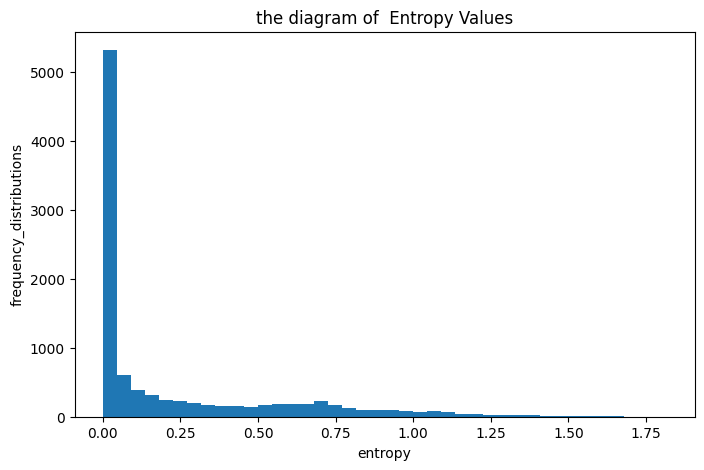

In [27]:
plt.figure(figsize=(8,5))

plt.hist(entropy_values, bins=40)

plt.title("the diagram of  Entropy Values")
plt.xlabel("entropy")
plt.ylabel("frequency_distributions")

plt.show()

/tmp/ipykernel_58/212420840.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


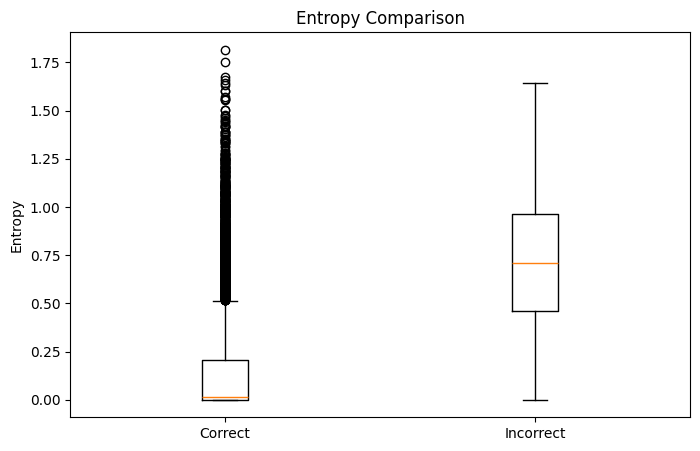

In [25]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [correct_entropy, incorrect_entropy],
    labels=['Correct', 'Incorrect']
)

plt.title("Entropy Comparison")
plt.ylabel("Entropy")

plt.show()

/tmp/ipykernel_58/3662599670.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


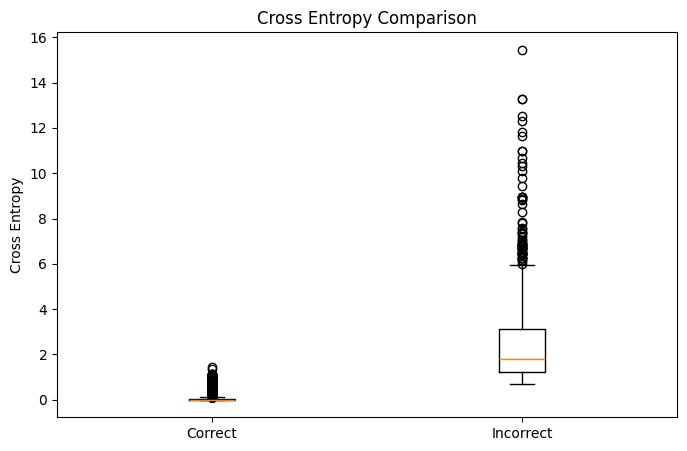

In [26]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [correct_ce, incorrect_ce],
    labels=['Correct', 'Incorrect']
)

plt.title("Cross Entropy Comparison")
plt.ylabel("Cross Entropy")

plt.show()

# High entropy (uncertain predictions)
# Low entropy (confident predictions)


In [29]:
high_entropy_indices = np.argsort(entropy_values)[-5:]

In [30]:
low_entropy_indices = np.argsort(entropy_values)[:5]

In [34]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

def show_examples(indices, title):

    plt.figure(figsize=(15,3))

    for i, idx in enumerate(indices):

        plt.subplot(1,5,i+1)

        plt.imshow(x_test[idx], cmap='gray')

        plt.axis('off')

        pred = pred_classes[idx]
        true = y_test[idx]

        entropy = entropy_values[idx]
        ce = cross_entropy_values[idx]

        plt.title(
            f"P:{class_names[pred]}\n"
            f"T:{class_names[true]}\n"
            f"H:{entropy:.2f}\n"
            f"CE:{ce:.2f}"
        )

    plt.suptitle(title)

    plt.show()

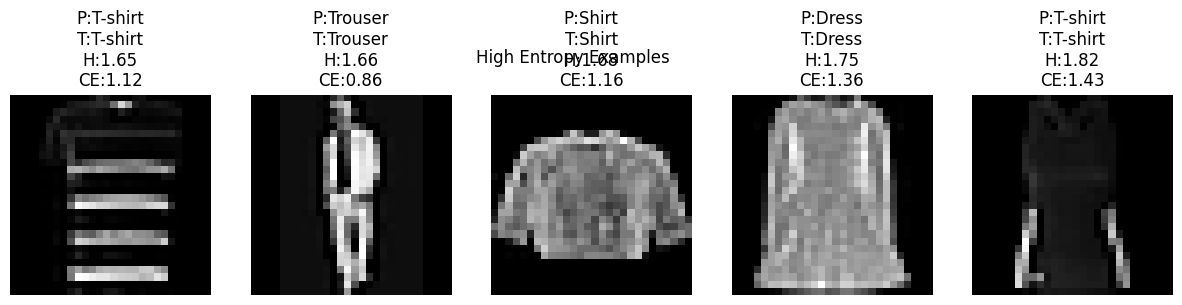

In [35]:
show_examples(
    high_entropy_indices,
    "High Entropy Examples"
)

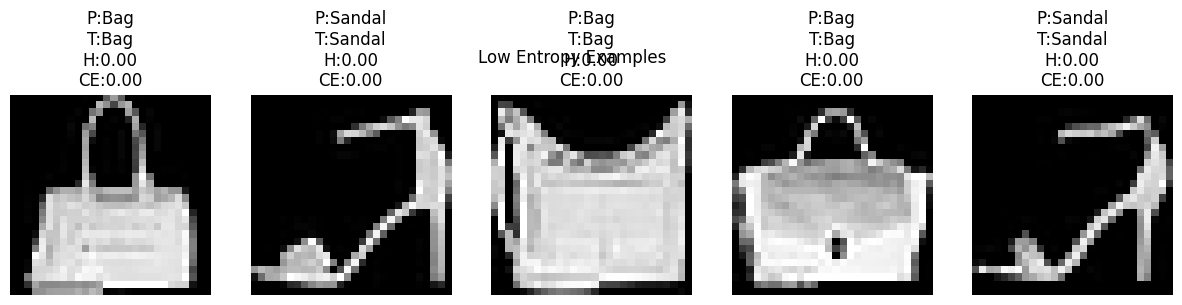

In [36]:
show_examples(
    low_entropy_indices,
    "Low Entropy Examples"
)